# TUGAS Data Science - Dokumentasi Praktikum
## Pertemuan 10: Algoritma Klasifikasi (Bagian 2) - Random Forest & Imbalanced Dataset

* **Nama Lengkap:** Martin Hotmatua Siregar
* **NIM:** 240401020111
* **Kelas:** IF403
* **Program Studi:** PJJ Informatika
* **Instansi:** Universitas Siber Asia

## Langkah 1 & 2: Pembuatan Dataset Telco Churn (Imbalanced) & Train-Test Split
Kita membuat simulasi dataset perilaku pelanggan telekomunikasi dengan kondisi tidak seimbang (imbalanced data ~20% churn). Kemudian data dibagi menjadi 80% Data Latih dan 20% Data Uji secara terstratifikasi (Stratified Split).

In [1]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Langkah 1: Menyiapkan dataset simulasi Customer Churn (Imbalanced ~20% Churn)
np.random.seed(42)
n_samples = 1000

tenure = np.random.exponential(scale=20, size=n_samples).clip(1, 72).astype(int)
monthly_charges = np.random.uniform(20, 120, size=n_samples)
contract = np.random.choice([0, 1, 2], size=n_samples, p=[0.55, 0.25, 0.20]) # 0: Month-to-month, 1: 1-Yr, 2: 2-Yr
tech_support = np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3])

# Logika probabilitas churn (Month-to-month + tagihan tinggi + tenure rendah -> churn tinggi)
logit = (monthly_charges * 0.03) - (tenure * 0.05) - (contract * 1.2) - (tech_support * 0.8) - 0.5
prob_churn = 1 / (1 + np.exp(-logit))
churn = (np.random.rand(n_samples) < prob_churn).astype(int)

df_churn = pd.DataFrame({
    'Tenure_Months': tenure,
    'MonthlyCharges': monthly_charges,
    'ContractType': contract,
    'TechSupport': tech_support,
    'Churn': churn
})

print("=== DISTRIBUSI KELAS TARGET (CHURN) ===")
print(df_churn['Churn'].value_counts(normalize=True).round(3))

# Langkah 2: Memisahkan Fitur (X) dan Target (y) serta Split Data
X = df_churn.drop('Churn', axis=1)
y = df_churn['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nUkuran Data Latih: {X_train.shape}")
print(f"Ukuran Data Uji   : {X_test.shape}")

=== DISTRIBUSI KELAS TARGET (CHURN) ===
Churn
0    0.548
1    0.452
Name: proportion, dtype: float64

Ukuran Data Latih: (800, 4)
Ukuran Data Uji   : (200, 4)


## Langkah 3 s.d 5: Pelatihan Random Forest dengan Penanganan Imbalance & Evaluasi Lengkap
Kita melatih model Random Forest menggunakan parameter `class_weight='balanced'` untuk menangani data yang tidak seimbang. Kemudian kita evaluasi model dengan Confusion Matrix Heatmap, metrik klasifikasi lengkap, dan Feature Importance.

=== HASIL EVALUASI METRIK KLASIFIKASI ===
Accuracy  : 0.7100
Precision : 0.6739
Recall    : 0.6889
F1-Score  : 0.6813
ROC-AUC   : 0.7680


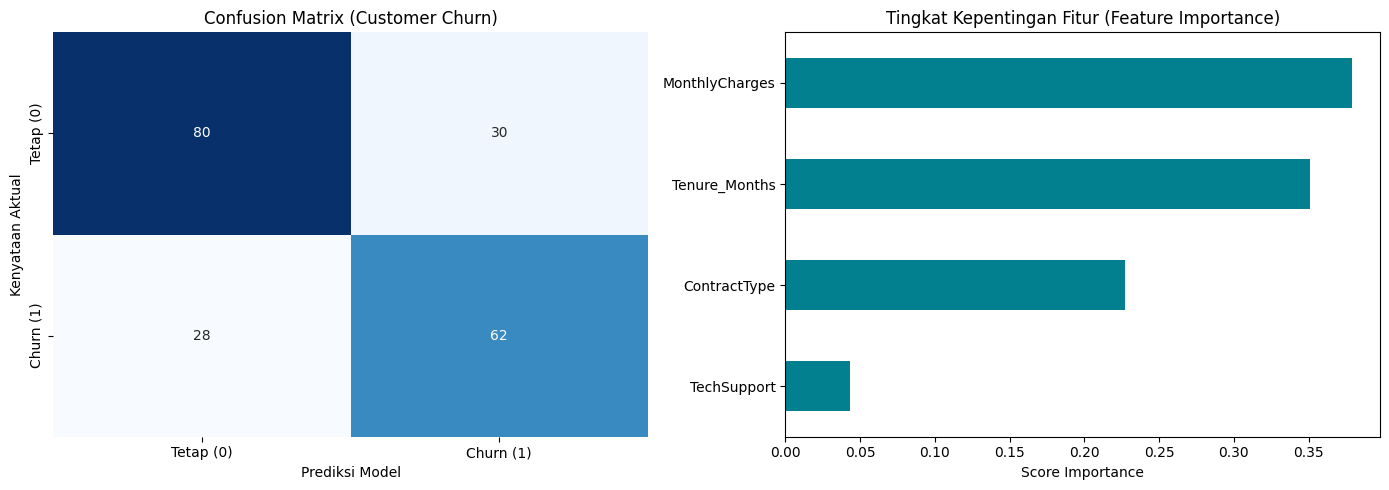


=== CONTOH PREDIKSI PROBABILITAS CHURN PELANGGAN ===


,Tenure_Months,MonthlyCharges,ContractType,TechSupport,Actual_Churn,Probabilitas_Churn,Prediksi
14,4,90.557517,0,0,1,0.863,1
165,36,101.796702,2,0,0,0.152,0
613,1,52.433375,1,1,1,0.454,0
446,72,89.262595,0,1,0,0.249,0
863,11,74.502692,1,0,1,0.406,0


In [2]:
# Langkah 3: Melatih Model Random Forest dengan class_weight='balanced'
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

# Langkah 4: Prediksi dan Perhitungan Metrik Evaluasi
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("=== HASIL EVALUASI METRIK KLASIFIKASI ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

# Langkah 5: Visualisasi Confusion Matrix & Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Heatmap Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Tetap (0)', 'Churn (1)'],
            yticklabels=['Tetap (0)', 'Churn (1)'])
axes[0].set_title('Confusion Matrix (Customer Churn)')
axes[0].set_xlabel('Prediksi Model')
axes[0].set_ylabel('Kenyataan Aktual')

# Plot 2: Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='#028090', ax=axes[1])
axes[1].set_title('Tingkat Kepentingan Fitur (Feature Importance)')
axes[1].set_xlabel('Score Importance')

plt.tight_layout()
plt.show()

# Menampilkan 5 contoh prediksi probabilitas churn pelanggan
df_hasil = X_test.copy()
df_hasil['Actual_Churn'] = y_test
df_hasil['Probabilitas_Churn'] = y_proba.round(3)
df_hasil['Prediksi'] = y_pred
print("\n=== CONTOH PREDIKSI PROBABILITAS CHURN PELANGGAN ===")
display(df_hasil.head())

## Interpretasi Bisnis & Pemilihan Metrik yang Tepat

### 1. Mengapa Akurasi Menyesatkan pada Kasus Imbalanced Data?
Pada kasus prediksi *Customer Churn*, mayoritas pelanggan biasanya bertahan (~80%) dan hanya sebagian kecil yang berhenti/churn (~20%). Jika sebuah model "bodoh" menebak semua pelanggan akan bertahan, model tersebut secara otomatis tetap memiliki **Akurasi 80%**, padahal model gagal mendeteksi satupun pelanggan yang kabur. Inilah yang disebut *Accuracy Paradox*.

### 2. Metrik yang Paling Relevan: Recall & F1-Score
* **Recall (Prioritas Utama):** Fokus meminimalkan *False Negative* (pelanggan yang sebenarnya mau churn tapi diprediksi bertahan). Kehilangan pelanggan jauh lebih mahal biayanya bagi perusahaan telekomunikasi dibanding memberikan promosi retensi kepada pelanggan yang salah tebak (*False Positive*).
* **F1-Score:** Memberikan gambaran keseimbangan yang adil antara *Precision* dan *Recall* tanpa tertipu oleh tingginya angka mayoritas.

## Kesimpulan & Refleksi Pembelajaran (Sesi 10)

### 1. Apa yang Dipelajari?
Pada pertemuan kesepuluh ini, saya mempelajari konsep metode *Ensemble Learning* menggunakan algoritma **Random Forest**, yang menggabungkan banyak *Decision Tree* melalui teknik *bootstrap aggregating* (bagging) dan pemilihan fitur acak. Saya juga mempraktikkan cara menangani *Imbalanced Dataset* menggunakan parameter penyeimbang bobot kelas (`class_weight='balanced'`).

### 2. Temuan Utama
* Random Forest terbukti lebih stabil dan memiliki variansi lebih rendah dibanding Decision Tree tunggal karena prinsip *wisdom of crowds*.
* Berdasarkan grafik *Feature Importance*, variabel durasi berlangganan (*Tenure*) dan jenis kontrak (*ContractType*) merupakan faktor paling dominan yang menentukan apakah seorang pelanggan akan churn atau bertahan.
* Probabilitas yang dihasilkan (`predict_proba`) sangat bermanfaat bagi tim bisnis/marketing untuk memprioritaskan pemberian voucher atau diskon retensi khusus kepada pelanggan dengan risiko churn di atas 70%.

### 3. Keterbatasan & Pertanyaan yang Muncul
* **Keterbatasan:** Penanganan imbalance pada praktikum ini masih menggunakan pembobotan kelas (*class weight*). Pada dataset dengan tingkat ketimpangan ekstrem (misal 99:1), teknik ini terkadang masih kalah efektif dibanding metode *oversampling* sintetis seperti SMOTE.
* **Pertanyaan:** Bagaimana cara menentukan batas ambang keputusan (*threshold tuning*) yang paling optimal secara matematis untuk menyeimbangkan biaya promosi retensi vs potensi pendapatan yang hilang akibat pelanggan churn?